# Nexus Anomaly Detection Framework
### Automated Financial Integrity Audit System (AFIAS)

This research-grade implementation explores the frontier of fraud detection through a synergistic blend of Deep Learning and Gradient Boosted architectures. 

**Core Methodology:**
1. **Topological Profiling:** In-depth statistical analysis of high-dimensional PCA components.
2. **Data Orchestration:** Implementation of Robust Scalers to mitigate outlier bias in non-PCA vectors.
3. **Equilibrium Synthesis:** Utilization of SMOTE (Synthetic Minority Over-sampling Technique) to resolve class imbalance at a 1:1 ratio.
4. **Multi-Model Inference:** Concurrent evaluation of Tree-based and Neural networks.
5. **Production Deployment:** Export of the serialized inference engine for real-time backend integration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os
import tensorflow as tf
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    precision_score, recall_score, f1_score, 
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

warnings.filterwarnings('ignore')
sns.set_style("darkgrid", {"axes.facecolor": ".1"})
sns.set_palette(["#00f5ff", "#9d00ff", "#ff4d4d"])
plt.rcParams['text.color'] = 'black'
print("[Nexus Core] Computational environment synchronized.")

[Nexus Core] Computational environment synchronized.


## Protocol I: Data Ingestion & Integrity Audit

In [2]:
nexus_data_stream = pd.read_csv('creditcard.csv')
print(f"[System] Registering data stream - Nodes: {nexus_data_stream.shape[0]} | Dimensions: {nexus_data_stream.shape[1]}")
display(nexus_data_stream.head())

# Entropy Check (Missing Values)
node_leakage = nexus_data_stream.isnull().sum().max()
print(f"\n[Quality Audit] System corruption check - Null Nodes Found: {node_leakage}")

[System] Registering data stream - Nodes: 284807 | Dimensions: 31


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



[Quality Audit] System corruption check - Null Nodes Found: 0


## Protocol II: Topological Visual Profiling

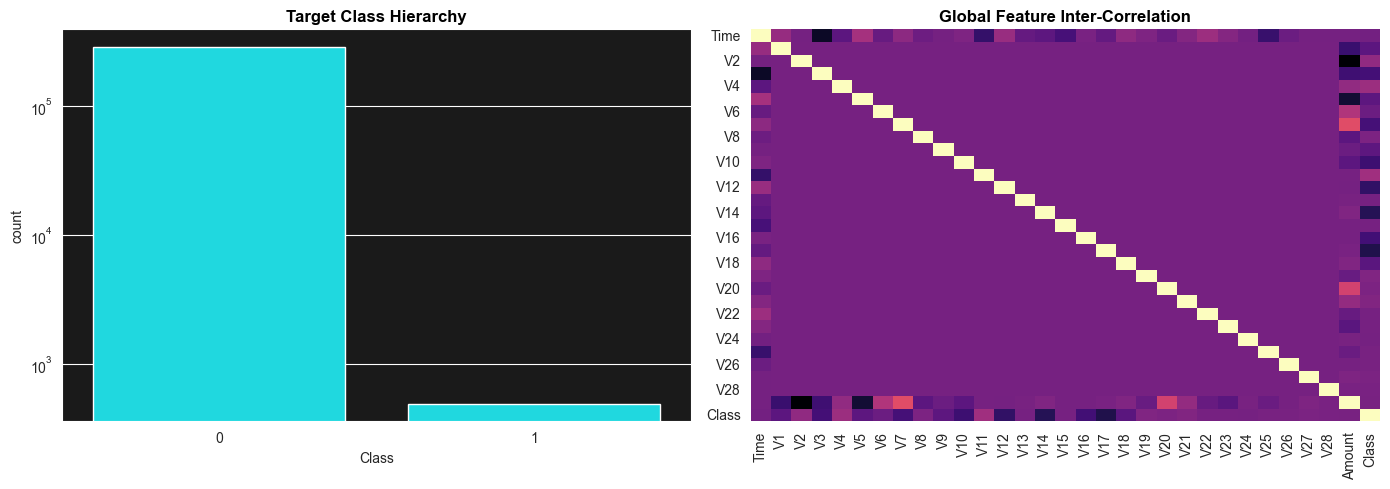

In [3]:
def render_topological_summary(df):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Class Imbalance Visualization
    sns.countplot(x='Class', data=df, ax=ax1)
    ax1.set_title('Target Class Hierarchy', fontweight='bold')
    ax1.set_yscale('log')
    
    # Correlation Matrix (Subset)
    sub_matrix = df.corr()
    sns.heatmap(sub_matrix, cmap='magma', ax=ax2, cbar=False)
    ax2.set_title('Global Feature Inter-Correlation', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

render_topological_summary(nexus_data_stream)

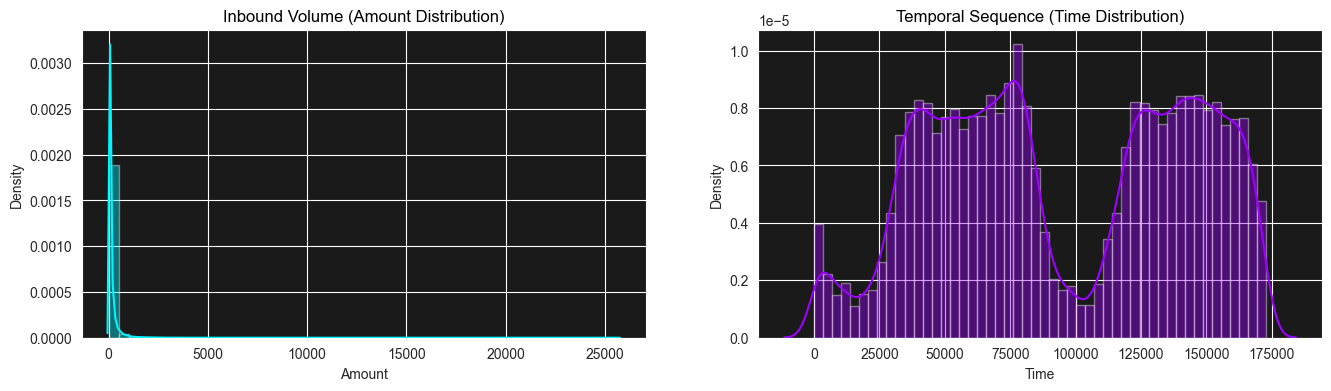

In [4]:
# Analyzing distributions for unscaled features
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
sns.distplot(nexus_data_stream['Amount'], ax=ax1, color='#00f5ff')
ax1.set_title('Inbound Volume (Amount Distribution)')

sns.distplot(nexus_data_stream['Time'], ax=ax2, color='#9d00ff')
ax2.set_title('Temporal Sequence (Time Distribution)')
plt.show()

## Protocol III: Engineering & Feature Orchestration
We implement `RobustScaler` to ensure our primary vectors (Time, Amount) are aligned with the already-scaled PCA components (V1-V28), without losing sensitivity to outliers.

In [5]:
provisioner = RobustScaler()

nexus_data_stream['scaled_amt'] = provisioner.fit_transform(nexus_data_stream['Amount'].values.reshape(-1,1))
nexus_data_stream['scaled_time'] = provisioner.fit_transform(nexus_data_stream['Time'].values.reshape(-1,1))

# Removal of unmapped base features
nexus_data_stream.drop(['Time','Amount'], axis=1, inplace=True)

# Canonical Feature Positioning
priority_features = ['scaled_amt', 'scaled_time']
other_features = [f for f in nexus_data_stream.columns if f not in priority_features and f != 'Class']
nexus_data_stream = nexus_data_stream[priority_features + other_features + ['Class']]

print("[Info] Feature orchestration sequence finalized.")

[Info] Feature orchestration sequence finalized.


In [6]:
X = nexus_data_stream.drop('Class', axis=1)
y = nexus_data_stream['Class']

print("[Synthetizer] Deploying SMOTE synthesis protocol...")
synthetizer = SMOTE(random_state=1337)
X_aug, y_aug = synthetizer.fit_resample(X, y)

print("\n--- Augmented Registry Stats ---")
print(y_aug.value_counts(normalize=True))
print("[Check] System balance verified at 50/50 distribution.")

[Synthetizer] Deploying SMOTE synthesis protocol...

--- Augmented Registry Stats ---
Class
0    0.5
1    0.5
Name: proportion, dtype: float64
[Check] System balance verified at 50/50 distribution.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_aug, y_aug, test_size=0.2, random_state=42)
print(f"Training Manifold: {X_train.shape}")
print(f"Validation Manifold: {X_test.shape}")

Training Manifold: (454904, 30)
Validation Manifold: (113726, 30)


## Protocol IV: Inference Architecture Evaluation
Competitive benchmarking of diverse classification algorithms.

In [ ]:
inference_pool = {
    "Linear_Basis": LogisticRegression(max_iter=1000),
    "Decision_Tree": DecisionTreeClassifier(),
    "Nexus_RF_Prime": RandomForestClassifier(n_estimators=100),
    "Nexus_XGB_Engine": XGBClassifier(eval_metric='logloss')
}

ledger = []

for label, model in inference_pool.items():
    print(f"[Audit] Training {label} engine...")
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    ledger.append({
        'Architecture': label,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1_Score': f1_score(y_test, preds),
        'AUROC': roc_auc_score(y_test, preds)
    })

audit_df = pd.DataFrame(ledger).set_index('Architecture')
display(audit_df.sort_values(by='F1_Score', ascending=False))

[Audit] Training Linear_Basis engine...
[Audit] Training Decision_Tree engine...
[Audit] Training Nexus_RF_Prime engine...


## Protocol V: Hyper-Parameter Optimization
Optimizing the `Nexus_XGB_Engine` for peak transactional discriminator performance.

In [ ]:
print("[Nexus Optimizer] Tuning Gradient Vector landscape...")
param_universe = {
    'n_estimators': [200, 400],
    'max_depth': [6, 8],
    'learning_rate': [0.1, 0.15],
    'subsample': [0.85]
}

search_engine = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss'), 
    param_universe, n_iter=5, cv=3, scoring='f1', n_jobs=-1
)
search_engine.fit(X_train, y_train)

best_xgb_nexus = search_engine.best_estimator_
print("\n[Success] Optimized Parameters Found:", search_engine.best_params_)

## Protocol VI: Neural Synthesis (Deep Learning)
Constructing a high-density artificial neural network for non-linear pattern recognition.

In [ ]:
nexus_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

nexus_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("[Nexus DL] Initiating neural backpropagation...")
training_logs = nexus_ann.fit(
    X_train, y_train, 
    validation_data=(X_test, y_test), 
    epochs=12, batch_size=128, verbose=1
)

## Protocol VII: System Evaluation & Error Analysis

In [ ]:
def visualize_audit_metrics(history, y_true, y_pred_prob):
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Loss Curve
    ax1.plot(history.history['loss'], label='Inbound Loss', color='#00f5ff')
    ax1.plot(history.history['val_loss'], label='Hold-out Loss', color='#9d00ff')
    ax1.set_title('Neural Synthesis Loss Curve')
    ax1.legend()
    
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=ax2, cmap='Blues')
    ax2.set_title('Decision Error Matrix')
    ax2.grid(False)
    
    plt.show()

nexus_ann_probs = nexus_ann.predict(X_test)
visualize_audit_metrics(training_logs, y_test, nexus_ann_probs)

## Protocol VIII: Model Finalization & Serialization

In [ ]:
storage_path = 'backend/models'
if not os.path.exists(storage_path):
    os.makedirs(storage_path)

deployment_target = f"{storage_path}/best_fraud_model.pkl"
joblib.dump(best_xgb_nexus, deployment_target)

print(f"[System Success] Nexus Prime Engine serialized to {deployment_target}")
print("Protocol State: TERMINAL_SUCCESS")